<a href="https://colab.research.google.com/github/Apekshya175/AI-ML/blob/main/Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import random

seed = 123

tf.keras.utils.set_random_seed(seed)
tf.config.experimental.enable_op_determinism()

np.random.seed(seed)
random.seed(seed)

In [ ]:

import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip'
data_path = '/content/drive/MyDrive/AI ML/Data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip' to '/content/drive/MyDrive/AI ML'


In [ ]:

import os
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

TASK 1 Loading dataset

In [ ]:
train_dir = "/content/drive/MyDrive/AI ML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI ML/FruitinAmazon/test"


In [ ]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Class directories found:")
print(class_names)
print("Total number of classes:", len(class_names))

Class directories found:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total number of classes: 6


In [ ]:
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ]

    if len(image_files) > 0:
        random_image = random.choice(image_files)
        image_path = os.path.join(class_path, random_image)
        sample_images.append((class_name, image_path))

print("Total sampled images:", len(sample_images))

Total sampled images: 6


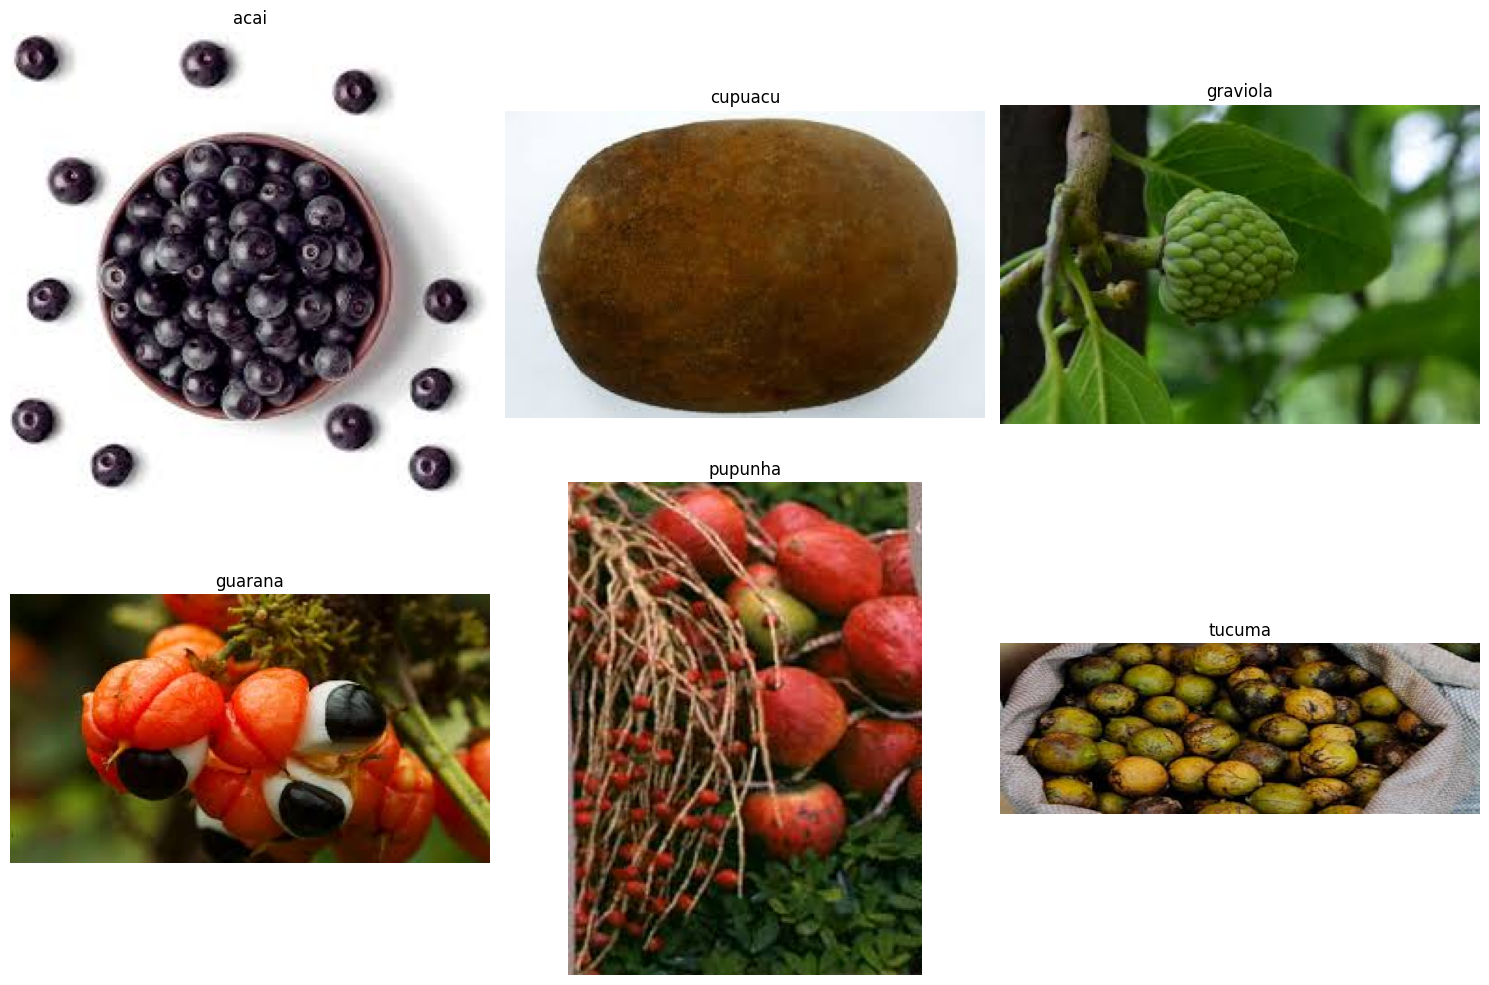

In [ ]:
rows = 2
cols = math.ceil(len(sample_images) / rows)

plt.figure(figsize=(5 * cols, 5 * rows))

for i, (class_name, image_path) in enumerate(sample_images, 1):
    img = Image.open(image_path)

    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(class_name, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

Observation:
The dataset consists of multiple fruit categories with distinct visual features.
There is noticeable variation in color, shape, and texture among classes.
Some classes have similar visual characteristics, which may lead to misclassification.

In [ ]:
from PIL import Image, UnidentifiedImageError
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)

        if os.path.isfile(file_path):
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError, UnidentifiedImageError):
                corrupted_images.append(file_path)
                os.remove(file_path)
                print(f"Removed corrupted image: {file_path}")
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print("Total corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


Task 2 Preprocessing

In [ ]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1. / 255)

raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)

train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds = raw_val_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6
Image batch shape: (16, 128, 128, 3)
Label batch shape: (16,)


In Task 2, the image data was loaded from the train directory using image_dataset_from_directory in Keras. The images were resized to 128 × 128 pixels, labels were automatically inferred from the subdirectory names, and the dataset was divided into training and validation sets using an 80:20 split. A batch size of 16 was used. After loading, the images were normalized using a Rescaling layer so that pixel values were converted from the range [0, 255] to [0, 1]. Finally, prefetching was applied to improve input pipeline performance during model training.

Task 3 Build Model


In [ ]:
from tensorflow.keras import models, layers




model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),


    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 3 Explanation:
A Convolutional Neural Network was implemented for multi-class fruit image classification.
The model starts with an input layer that accepts color images of size 128x128x3.
It contains two convolutional layers, each using 32 filters of size 3x3 with same padding
and ReLU activation. After each convolutional layer, max pooling with pool size 2x2 and
stride 2 is applied to reduce spatial dimensions. The extracted feature maps are then flattened
and passed through two fully connected dense layers with 64 and 128 neurons respectively.
Finally, the output layer uses softmax activation with num_classes neurons to perform
multi-class classification.

Task 4 Compile the model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.1594 - loss: 2.0783
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 470ms/step - accuracy: 0.1667 - loss: 2.0475 - val_accuracy: 0.1111 - val_loss: 2.0956
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.3257 - loss: 1.7726
Epoch 2: val_accuracy improved from 0.11111 to 0.66667, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - accuracy: 0.4722 - loss: 1.6593 - val_accuracy: 0.6667 - val_loss: 1.1913
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.4625 - loss: 1.4318
Epoch 3: val_accuracy improved from 0.66667 to 0.72222, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - accuracy: 0.4583 - loss: 1.3515 - val_accuracy: 0.7222 - val_loss: 1.0455
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.5788 - loss: 1.1593
Epoch 4: val_accuracy improved from 0.72222 to 0.83333, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - accuracy: 0.6389 - loss: 1.0819 - val_accuracy: 0.8333 - val_loss: 0.8357
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.6188 - loss: 0.8965
Epoch 5: val_accuracy improved from 0.83333 to 0.94444, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 626ms/step - accuracy: 0.6250 - loss: 0.8797 - val_accuracy: 0.9444 - val_loss: 0.3757
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8309 - loss: 0.6798
Epoch 6: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.8056 - loss: 0.6612 - val_accuracy: 0.6111 - val_loss: 0.9634
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.8781 - loss: 0.4590
Epoch 7: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 372ms/step - accuracy: 0.9167 - loss: 0.3991 - val_accuracy: 0.9444 - val_loss: 0.3399
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9184 - loss: 0.2423
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.9306 - loss: 0.2288 - val_accuracy: 0.8333 - val_loss: 0.4438
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 1.0000 - loss:

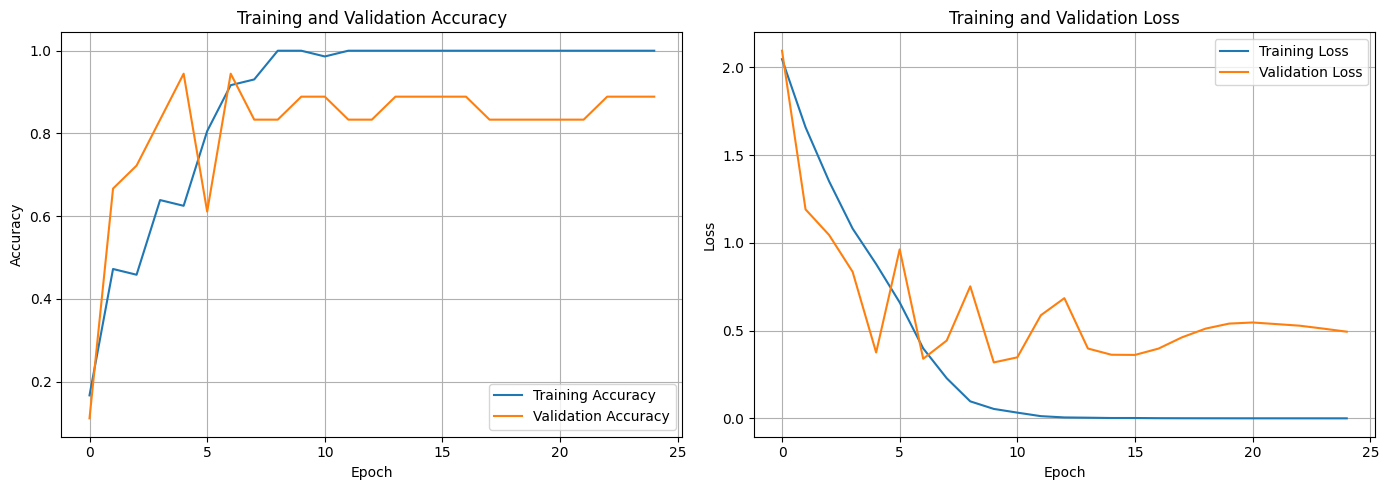

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Task 4 Explanation:
The CNN model was compiled using the Adam optimizer, sparse categorical crossentropy
as the loss function, and accuracy as the evaluation metric. The model was then trained
using the training dataset and validated on the validation dataset for up to 250 epochs.
To improve training, ModelCheckpoint was used to save the best-performing model based on
validation accuracy, and EarlyStopping was used to stop training early if the validation
loss stopped improving, which helps reduce overfitting.


Task 5

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8333 - loss: 0.7986
Test Loss: 0.798588216304779
Test Accuracy: 0.8333333134651184


Task 5 Explanation:
In this task, the trained CNN model was evaluated using the test dataset.
The test images were loaded from the test directory, resized to 128x128,
batched, and normalized in the same way as the training and validation data.
Then, model.evaluate() was used to calculate the test loss and test accuracy.
These values show how well the trained model performs on unseen data.

In [ ]:
model.save('fruit_classification_model.h5')
print("Model saved successfully as fruit_classification_model.h5")


loaded_model = tf.keras.models.load_model('fruit_classification_model.h5')
print("Model loaded successfully.")

loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_test_loss)
print("Loaded Model Test Accuracy:", loaded_test_accuracy)

Model saved successfully as fruit_classification_model.h5


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8333 - loss: 0.7986
Loaded Model Test Loss: 0.798588216304779
Loaded Model Test Accuracy: 0.8333333134651184


Task 6 Explanation:
In this task, the trained CNN model was saved in H5 format using model.save().
This allows the trained model to be reused later without retraining. After saving,
the model was loaded again using tf.keras.models.load_model(). The loaded model
was then evaluated on the test dataset to confirm that the saved and loaded model
retained the same performance as the original trained model.

Task 7


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)


print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

True labels shape: (30,)
Predicted labels shape: (30,)
Classification Report:

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.57      0.80      0.67         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.83        30
   macro avg       0.87      0.83      0.82        30
weighted avg       0.87      0.83      0.82        30



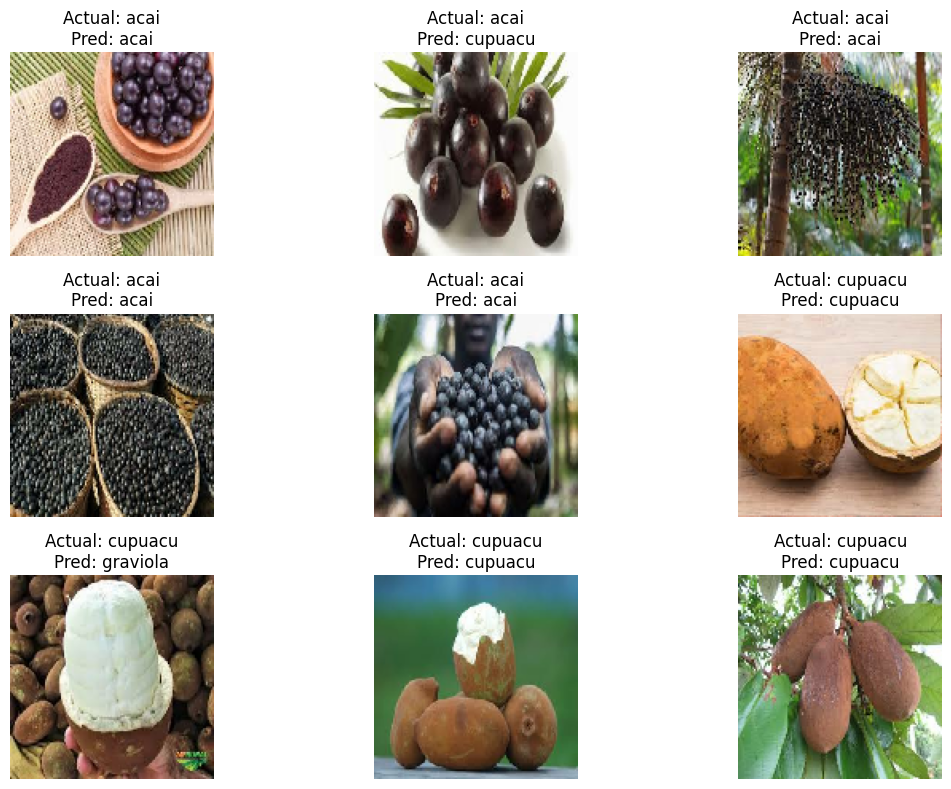

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Actual: {class_names[labels[i].numpy()]}\nPred: {class_names[predicted_labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(len(images)):
        if predicted_labels[i] != labels[i].numpy():
            misclassified_images.append(images[i].numpy())
            misclassified_true.append(labels[i].numpy())
            misclassified_pred.append(predicted_labels[i])

print("Total misclassified images:", len(misclassified_images))

Total misclassified images: 5


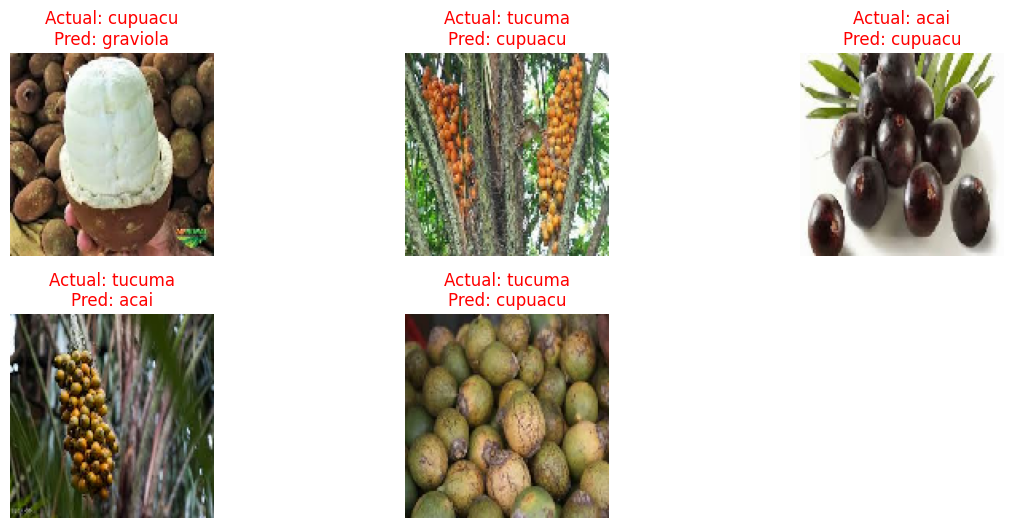

In [ ]:
import random

num_to_show = min(9, len(misclassified_images))
indices = random.sample(range(len(misclassified_images)), num_to_show)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(misclassified_images[idx])

    true_label = class_names[misclassified_true[idx]]
    pred_label = class_names[misclassified_pred[idx]]

    plt.title(f"Actual: {true_label}\nPred: {pred_label}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

test_loss, test_accuracy = loaded_model.evaluate(test_ds, verbose=0)

print("Final Results:\n")
print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

Final Results:

Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
Test Accuracy       : 0.8333
